<a href="https://colab.research.google.com/github/alfred-peter/Data-Wrangling/blob/main/Airplane_Crashes_Data_Cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

190285 - Kilonzo Alfred Peter Mbuvi

190027 - Njoroge Moses Mugo

165767 - Makedi Duane Barrack


In [1]:
import kagglehub

path = kagglehub.dataset_download("saurograndi/airplane-crashes-since-1908")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'airplane-crashes-since-1908' dataset.
Path to dataset files: /kaggle/input/airplane-crashes-since-1908


In [2]:
import os
print(os.listdir(path))

['Airplane_Crashes_and_Fatalities_Since_1908.csv']


In [4]:
import pandas as pd

df = pd.read_csv(f"{path}/Airplane_Crashes_and_Fatalities_Since_1908.csv")
df.head()

,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary
0,09/17/1908,17:18,"Fort Myer, Virginia",Military - U.S. Army,NaN,Demonstration,Wright Flyer III,NaN,1,2.0,1.0,0.0,"During a demonstration flight, a U.S. Army fly..."
1,07/12/1912,06:30,"AtlantiCity, New Jersey",Military - U.S. Navy,NaN,Test flight,Dirigible,NaN,NaN,5.0,5.0,0.0,First U.S. dirigible Akron exploded just offsh...
2,08/06/1913,NaN,"Victoria, British Columbia, Canada",Private,-,NaN,Curtiss seaplane,NaN,NaN,1.0,1.0,0.0,The first fatal airplane accident in Canada oc...
3,09/09/1913,18:30,Over the North Sea,Military - German Navy,NaN,NaN,Zeppelin L-1 (airship),NaN,NaN,20.0,14.0,0.0,The airship flew into a thunderstorm and encou...
4,10/17/1913,10:30,"Near Johannisthal, Germany",Military - German Navy,NaN,NaN,Zeppelin L-2 (airship),NaN,NaN,30.0,30.0,0.0,Hydrogen gas which was being vented was sucked...


2.  Determine the number of rows and columns in the dataset

In [7]:
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

Rows: 5268, Columns: 13


3. Display the last 75 rows in the dataset.


In [8]:
df.tail(75)

,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary
5193,03/15/2008,08:15,"Nbagu, Nigeria",Trade Wings Aviation Ltd.,NaN,Lagos - Bebi Air Strip,Beechcraft 1900D,5N-JAH,UE-322,3.0,3.0,0.0,The plane crashed while en route. Wreckage was...
5194,04/03/2008,11:00,"Lawa, Suriname",Blue Wing Airlines,NaN,Paramaribo - Lawa,Antonov An-28,PZ-TSO,1AJ007-17,19.0,19.0,0.0,While attempting to land the crew aborted the ...
5195,04/09/2008,23:27,"Bundeena, Australia",Avtex Air Services,NaN,Sydney - Brisbane,Swearingen SA227AC Metroliner III,VH-OZA,AC-600,1.0,1.0,0.0,The pilot of the mail plane reported some mino...
5196,04/11/2008,22:15,"Chrisinau, Moldova",Kata Transportation,NaN,"Chrisinau, Moldova - Antalya, Turkey - Sudan",Antonov An-32,ST-AZL,3009,8.0,8.0,0.0,Just minutes after the take off the plane trie...
5197,04/15/2008,14:30,"Goma, Congo",Hewa Bora Airways,NaN,Goma - Kisangani - Kinshasa,McDonnell Douglas DC-9-51,9Q-CHN,47731,85.0,0.0,47.0,"While attempting to takeoff, the plane failed ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5263,05/20/2009,06:30,"Near Madiun, Indonesia",Military - Indonesian Air Force,NaN,Jakarta - Maduin,Lockheed C-130 Hercules,A-1325,1982,112.0,98.0,2.0,"While on approach, the military transport cras..."
5264,05/26/2009,NaN,"Near Isiro, DemocratiRepubliCongo",Service Air,NaN,Goma - Isiro,Antonov An-26,9Q-CSA,5005,4.0,4.0,NaN,The cargo plane crashed while on approach to I...
5265,06/01/2009,00:15,"AtlantiOcean, 570 miles northeast of Natal, Br...",Air France,447,Rio de Janeiro - Paris,Airbus A330-203,F-GZCP,660,228.0,228.0,0.0,The Airbus went missing over the AtlantiOcean ...
5266,06/07/2009,08:30,"Near Port Hope Simpson, Newfoundland, Canada",Strait Air,NaN,Lourdes de BlanSablon - Port Hope Simpson,Britten-Norman BN-2A-27 Islander,C-FJJR,424,1.0,1.0,0.0,The air ambulance crashed into hills while att...


4. Each column except the first one has some missing data. For each column, name
the most appropriate method for treating the missing data. Justify your choices.

In [9]:
df.isnull().sum()

,0
Date,0
Time,2219
Location,20
Operator,18
Flight #,4199
Route,1707
Type,27
Registration,335
cn/In,1228
Aboard,22


5. Create a new dataframe from the raw/uncleaned data called
‘fatality_locations’ with the following columns: ‘Date’,
‘Location’, ‘Aboard’, ‘Fatalities’.


In [10]:
fatality_locations = df[['Date', 'Location', 'Aboard', 'Fatalities']].copy()
fatality_locations.head()

,Date,Location,Aboard,Fatalities
0,09/17/1908,"Fort Myer, Virginia",2.0,1.0
1,07/12/1912,"AtlantiCity, New Jersey",5.0,5.0
2,08/06/1913,"Victoria, British Columbia, Canada",1.0,1.0
3,09/09/1913,Over the North Sea,20.0,14.0
4,10/17/1913,"Near Johannisthal, Germany",30.0,30.0


6. Determine the date of the highest number of recorded fatalities from this new
dataframe.

In [14]:
max_fatalities_row = fatality_locations.loc[fatality_locations['Fatalities'].idxmax()]
print(max_fatalities_row)

Date                        03/27/1977
Location      Tenerife, Canary Islands
Aboard                           644.0
Fatalities                       583.0
Name: 2963, dtype: object


7. Compare the number of passengers aboard to the number of fatalities per crash. Are
there any recorded crashes where there were no fatalities? If so, how many?


In [15]:
zero_fatalities = fatality_locations[fatality_locations['Fatalities'] == 0]
print(f"Number of crashes with no fatalities: {len(zero_fatalities)}")

Number of crashes with no fatalities: 58


In [16]:
fatality_locations['fatality_rate'] = fatality_locations['Fatalities'] / fatality_locations['Aboard']
fatality_locations[['Aboard', 'Fatalities', 'fatality_rate']].describe()

,Aboard,Fatalities,fatality_rate
count,5246.000000,5256.000000,5244.000000
mean,27.554518,20.068303,0.834932
std,43.076711,33.199952,0.298771
min,0.000000,0.000000,0.000000
25%,5.000000,3.000000,0.800000
50%,13.000000,9.000000,1.000000
75%,30.000000,23.000000,1.000000
max,644.000000,583.000000,1.000000


8.  In the ‘fatality_locations’ dataframe, the location column has data items
represented as ‘Region, U.S. State/Country’. Split this column to have two columns
of regions and states/countries

In [18]:
location_split = fatality_locations['Location'].str.split(',', n=1, expand=True)
fatality_locations['Region'] = location_split[0].str.strip()
fatality_locations['State_Country'] = location_split[1].str.strip()

fatality_locations.head()

,Date,Location,Aboard,Fatalities,fatality_rate,Region,State_Country
0,09/17/1908,"Fort Myer, Virginia",2.0,1.0,0.5,Fort Myer,Virginia
1,07/12/1912,"AtlantiCity, New Jersey",5.0,5.0,1.0,AtlantiCity,New Jersey
2,08/06/1913,"Victoria, British Columbia, Canada",1.0,1.0,1.0,Victoria,"British Columbia, Canada"
3,09/09/1913,Over the North Sea,20.0,14.0,0.7,Over the North Sea,None
4,10/17/1913,"Near Johannisthal, Germany",30.0,30.0,1.0,Near Johannisthal,Germany


In [23]:
fatality_locations['State_Country'].isnull().sum()

np.int64(207)

9. Order the dataframe by the number of fatalities from highest to lowest and select the
first 100.

In [19]:
top_100_fatalities = fatality_locations.sort_values('Fatalities', ascending=False).head(100)
top_100_fatalities.head()

,Date,Location,Aboard,Fatalities,fatality_rate,Region,State_Country
2963,03/27/1977,"Tenerife, Canary Islands",644.0,583.0,0.905280,Tenerife,Canary Islands
3568,08/12/1985,"Mt. Osutaka, near Ueno Village, Japan",524.0,520.0,0.992366,Mt. Osutaka,"near Ueno Village, Japan"
4455,11/12/1996,"Near Charkhidadri, India",349.0,349.0,1.000000,Near Charkhidadri,India
2726,03/03/1974,"Near Ermenonville, France",346.0,346.0,1.000000,Near Ermenonville,France
3562,06/23/1985,"AtlantiOcean, 110 miles West of Ireland",329.0,329.0,1.000000,AtlantiOcean,110 miles West of Ireland


10. Generate a pie chart that shows the distribution of the top 25 number of fatalities
per country/U.S. State.

In [20]:
top_25 = top_100_fatalities.nlargest(25, 'Fatalities')

In [21]:
fatalities_by_country = top_25.groupby('State_Country')['Fatalities'].sum().sort_values(ascending=False)
fatalities_by_country

,Fatalities
State_Country,
Canary Islands,583.0
Saudi Arabia,562.0
"near Ueno Village, Japan",520.0
India,349.0
France,346.0
110 miles West of Ireland,329.0
"near Bandar Abbas, Iran",290.0
Iran,275.0
Illinois,271.0


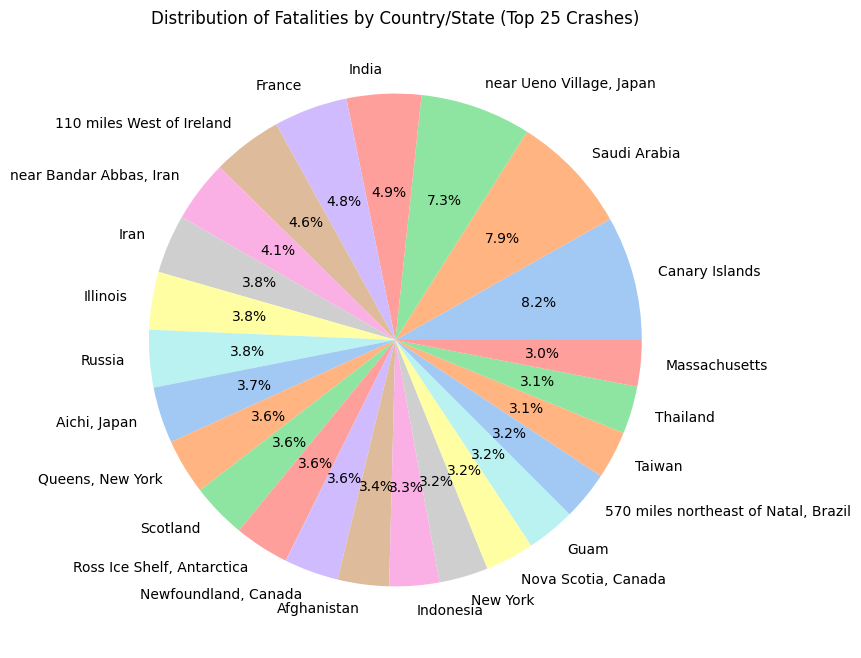

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

colors = sns.color_palette('pastel', len(fatalities_by_country))

plt.figure(figsize=(8, 8))
plt.pie(fatalities_by_country, labels=fatalities_by_country.index, autopct='%1.1f%%', colors=colors)
plt.title('Distribution of Fatalities by Country/State (Top 25 Crashes)')
plt.show()